In [3]:
import os
import numpy as np
import time
from pathlib import Path
import pickle
import pandas as pd
import traceback
from scipy import stats
import matplotlib.pyplot as plt
from galaxy_ellipse_collection import GalaxyEllipseCollection

#load configs
import sys
from config import db_connection, sys_path, results_output_directory, pickle_file
os.environ['TANGOS_DB_CONNECTION'] = '/home/bk639/data_base/CDM_all_shapes.db'
os.environ['TANGOS_PROPERTY_MODULES'] = 'mytangosproperty'
sys.path.append(sys_path)
import tangos
from MCMC_sims import get_keys,smooth_shape, load_and_process_halo_data

with open(pickle_file, 'rb') as f:
    ellipse_dict = pickle.load(f)


filepath='results/summary/all_individual_results_3Reff.pkl'

with open(filepath,'rb') as f:
    results = pickle.load(f)

/home/bk639/miniconda3/envs/pynbody/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def extract_single_value(value):
    """Extract scalar value from potentially nested data structures"""
    if isinstance(value, list):
        return value[0]
    return float(value)

In [5]:
records = []
radius = 2.5
for sim in ellipse_dict:
    halo_refs = list(ellipse_dict[sim].keys())
    #get feedback type if possible
    feedback_type = None
    if sim.endswith('sbBH'):
        feedback_type = 'sbBH'
    elif sim.endswith('bwK1BH'):
        feedback_type = 'bwBH'


    # --- Filter: Massive Merians (r* sims) — keep only most massive halo ---
    if sim.startswith('r') and not sim.startswith('rogue'):
        max_halo_ref, max_stars = None, 0
        for halo_ref in halo_refs:
            try:
                n_stars = tangos.get_halo(halo_ref)['n_star'][0]
                if n_stars > max_stars:
                    max_stars, max_halo_ref = n_stars, halo_ref
            except Exception:
                continue
        halo_refs = [max_halo_ref] if max_halo_ref else []
        print(f'Keeping only most massive halo from sim {sim}')

    # --- Filter: h* sims — skip halo 0 ---
    elif sim.startswith('h'):
        halo_refs = [hr for hr in halo_refs
                     if tangos.get_halo(hr).basename.split('_')[1] != '0']
        print(f'Removing halo 0 from sim {sim}')

    for halo_ref in halo_refs:
        try:

            halo  = tangos.get_halo(halo_ref)
            hid   = halo.basename.split('_')[1]
            #reff  = halo[f'image_reffs_{band}'][0] #replace this line
            #reff = get_keys(sim,hid,(0,0),'Reff')
            try:
                a = halo['a_s']
                b = halo['b_s']
                c = halo['c_s']
                rbins = halo['rbins_s']
            except Exception:
                print(f'no shape found for {sim} {hid}')
                continue
            Reff = get_keys(sim, hid, (0.0, 0.0), 'Reff')

            rbins_f, a_f, b_f, c_f, a_s_func, b_s_func, c_s_func = smooth_shape(rbins, a, b, c, k=3)
            # get a,b,c at 2*reff
            a_s = a_s_func(radius * Reff)
            b_s = b_s_func(radius * Reff)
            c_s = c_s_func(radius * Reff)
            ba_s = b_s/a_s
            ca_s = c_s/a_s


            # if Klein_comparison:
            #     ba_s, ca_s = halo['ba_s_v'], halo['ca_s_v']
            # else:
            #     rbins_s = halo['rbins_s']
            #     #show a warning if reff is more than 10% larger than largest rbin
            #     max_r = rbins_s[-1]
            #     if radius * reff > 1.1* max_r:
            #         print(f'Warning: {radius}*reff {radius* reff} vs max rbin {rbins_s[-1]} for halo {halo_ref}')
            #     ba_s  = halo.calculate('ba_s_smoothed()')(radius * reff)
            #     ca_s  = halo.calculate('ca_s_smoothed()')(radius * reff)

            try:
                stellar_mass = halo['M_star']
            except KeyError:
                stellar_mass = halo['finder_star_mass']

            stellar_mass    = extract_single_value(stellar_mass)
            log_stellar_mass = np.log10(stellar_mass)

            assert 0 <= ba_s <= 1
            assert 0 <= ca_s <= 1

        except Exception as e:
            print(f"\nError loading halo from {sim} {halo}: {e}")
            traceback.print_exc()
            skipped_count += 1
            continue

        halo_data = load_and_process_halo_data(pickle_file, sim, halo_ref)
        halo_data['a_s'], halo_data['ba_s'], halo_data['ca_s'] = a_s, ba_s,ca_s

        triaxiality = (a_s**2-b_s**2)/(a_s**2-c_s**2)
        records.append({
            'Simulation': sim,
            'Halo_ID': hid,
            'a_s': a_s, 'b_s': b_s, 'c_s': c_s,
            'ba': ba_s, 'ca': ca_s,
            'triaxiality': triaxiality,
        })

    #except:
        #print(f'could not get data for sim: {sim},halo: {hid}')

shape_df = pd.DataFrame(records)
df = pd.read_csv('results/summary/all_halos_summary.csv')
shape_df['Halo_ID'] = shape_df['Halo_ID'].astype(int)   # or df['Halo_ID'].astype(str)
df = df.merge(shape_df, on=['Simulation', 'Halo_ID'], how='left')

Keeping only most massive halo from sim r431.romulus25.3072g1HsbBH


/home/bk639/miniconda3/envs/pynbody/lib/python3.14/site-packages/scipy/interpolate/_fitpack_py.py:307: RuntimeWarning: The maximal number of iterations (20) allowed for finding smoothing
spline with fp=s has been reached. Probable cause: s too small.
(abs(fp-s)/s>0.001)
  res = _impl.splrep(x, y, w, xb, xe, k, task, s, t, full_output, per, quiet)


Removing halo 0 from sim h148.cosmo50PLK.3072g3HbwK1BH
Removing halo 0 from sim h229.cosmo50PLK.3072gst5HbwK1BH
Removing halo 0 from sim h242.cosmo50PLK.3072gst5HbwK1BH
Removing halo 0 from sim h329.cosmo50PLK.3072gst5HbwK1BH
Keeping only most massive halo from sim r1023.romulus25.3072g1HsbBH
Keeping only most massive halo from sim r442.romulus25.3072g1HsbBH
Keeping only most massive halo from sim r468.romulus25.3072g1HsbBH
Keeping only most massive halo from sim r488.romulus25.3072g1HsbBH
Keeping only most massive halo from sim r489.romulus25.3072g1HsbBH
Keeping only most massive halo from sim r492.romulus25.3072g1HsbBH
Keeping only most massive halo from sim r502.romulus25.3072g1HsbBH
Keeping only most massive halo from sim r515.romulus25.3072g1HsbBH
Keeping only most massive halo from sim r523.romulus25.3072g1HsbBH
Keeping only most massive halo from sim r544.romulus25.3072g1HsbBH
Keeping only most massive halo from sim r552.romulus25.3072g1HsbBH
Keeping only most massive halo from 

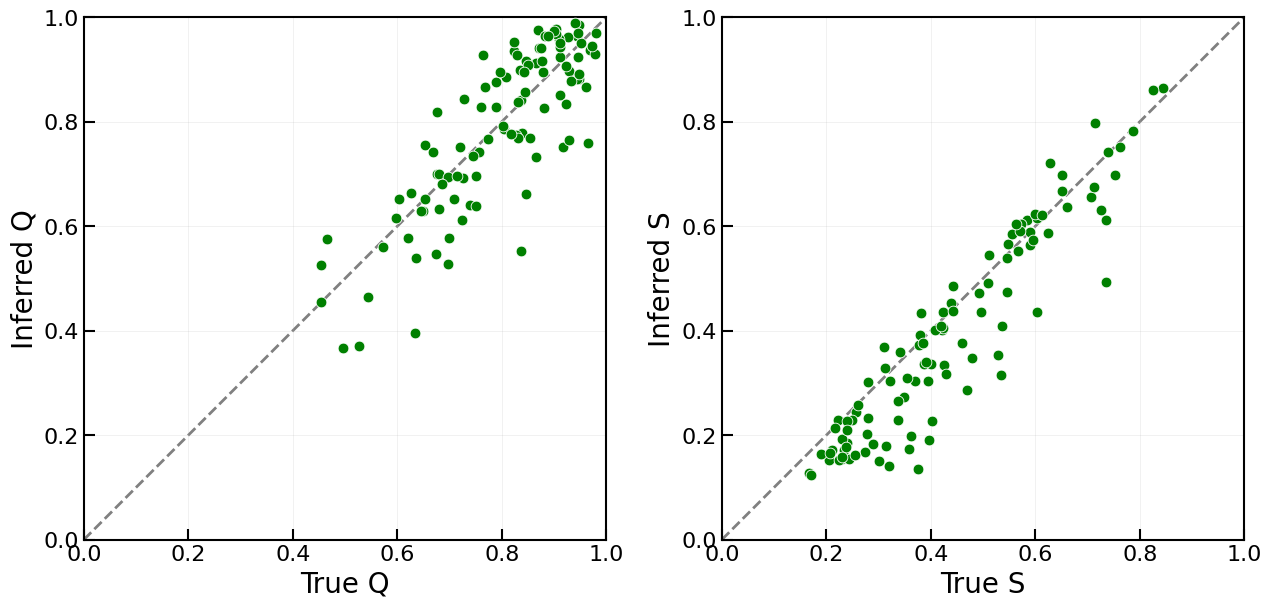

In [6]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 20,
    'axes.linewidth': 1.5,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'xtick.direction': 'in', 'ytick.direction': 'in',

    'xtick.major.size': 8, 'ytick.major.size': 8,
    'xtick.minor.size': 4, 'ytick.minor.size': 4,
    'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
})

fig, ax = plt.subplots(1, 2, figsize=(13, 6.5))

kw = dict(s=60, alpha=1, edgecolor='white', linewidth=0.6, color='green', zorder=3)
ax[0].scatter(df['ba'], df['Inferred B/A'], **kw)
ax[1].scatter(df['ca'], df['Inferred C/A'], **kw)

for a, lab in zip(ax, ['Q', 'S']):
    a.plot([0, 1], [0, 1], ls='--', c='gray', lw=2, zorder=1)
    a.set(xlim=(0, 1), ylim=(0, 1), aspect='equal')
    a.set_xlabel(f'True {lab}')
    a.set_ylabel(f'Inferred {lab}')

    a.grid(alpha=0.25, zorder=0)

fig.tight_layout()

$y=0.9994x-0.0089$
$r=0.8373$
$y=1.0680x-0.0754$
$r=0.9358$


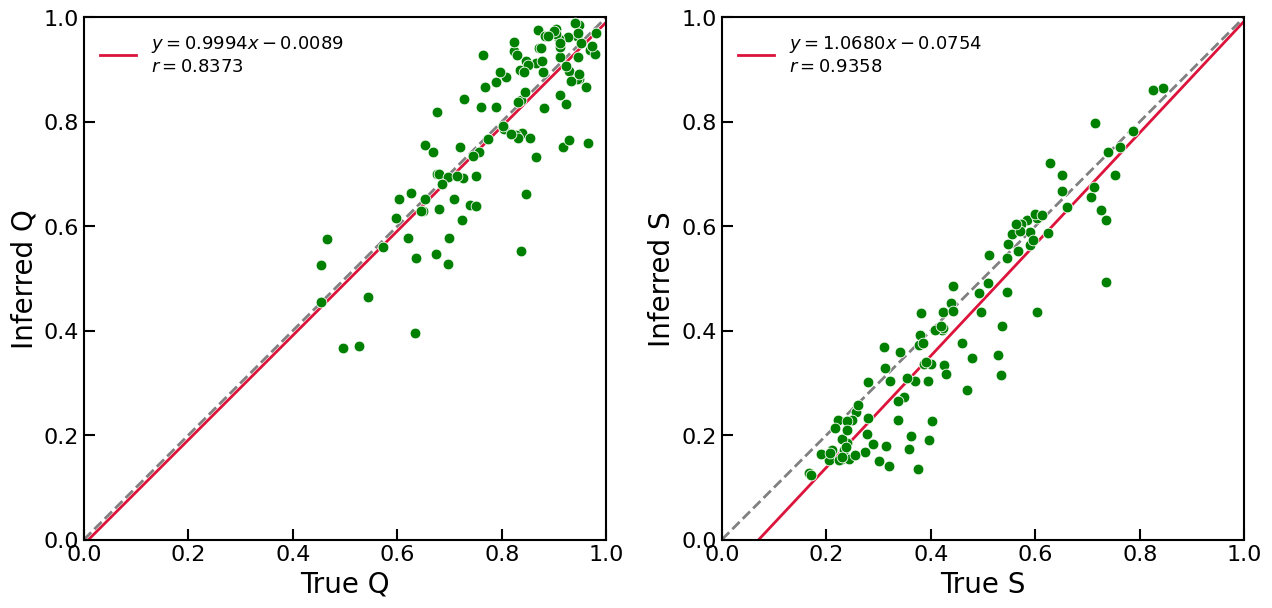

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 20,
    'axes.linewidth': 1.5,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'xtick.direction': 'in', 'ytick.direction': 'in',

    'xtick.major.size': 8, 'ytick.major.size': 8,
    'xtick.minor.size': 4, 'ytick.minor.size': 4,
    'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
})

fig, ax = plt.subplots(1, 2, figsize=(13, 6.5))

kw = dict(s=60, alpha=1, edgecolor='white', linewidth=0.6, color='green', zorder=3)
ax[0].scatter(df['ba'], df['Inferred B/A'], **kw)
ax[1].scatter(df['ca'], df['Inferred C/A'], **kw)

pairs = [('ba', 'Inferred B/A'), ('ca', 'Inferred C/A')]

for a, lab, (xcol, ycol) in zip(ax, ['Q', 'S'], pairs):
    x = df[xcol].to_numpy(float)
    y = df[ycol].to_numpy(float)
    m = np.isfinite(x) & np.isfinite(y)          # drop NaNs so polyfit doesn't choke
    slope, intercept = np.polyfit(x[m], y[m], 1)
    r = np.corrcoef(x[m], y[m])[0, 1]

    xx = np.linspace(0, 1, 100)
    a.plot(xx, slope * xx + intercept, c='crimson', lw=2, zorder=2,
           label=f'$y={slope:.4f}x{intercept:+.4f}$\n$r={r:.4f}$')
    print(f'$y={slope:.4f}x{intercept:+.4f}$\n$r={r:.4f}$')

    a.plot([0, 1], [0, 1], ls='--', c='gray', lw=2, zorder=1)
    a.set(xlim=(0, 1), ylim=(0, 1), aspect='equal')
    a.set_xlabel(f'True {lab}')
    a.set_ylabel(f'Inferred {lab}')
    a.legend(loc='upper left', fontsize=13, frameon=False)


fig.tight_layout()

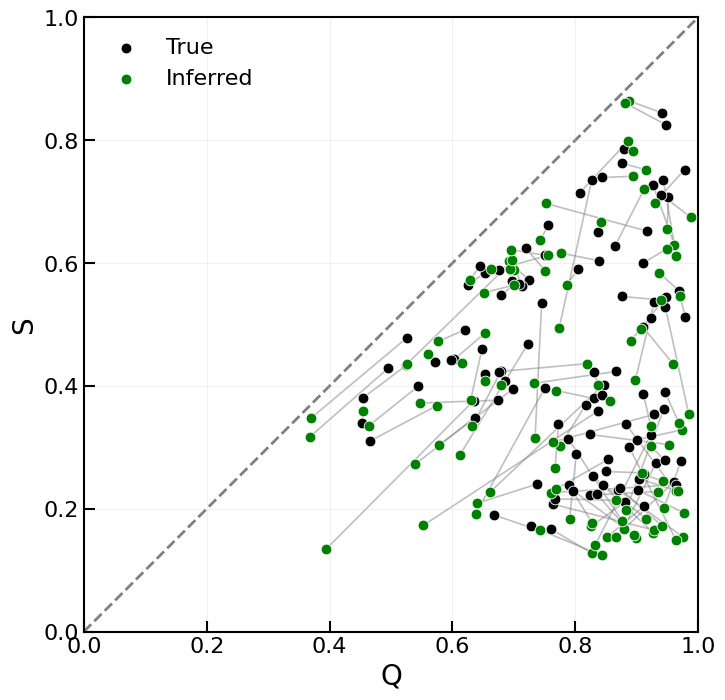

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 20,
    'axes.linewidth': 1.5,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.major.size': 8, 'ytick.major.size': 8,
    'xtick.minor.size': 4, 'ytick.minor.size': 4,
    'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
})

fig, a = plt.subplots(1, 1, figsize=(7.5, 7.5))

ba_true, ca_true = df['ba'].values, df['ca'].values
ba_inf,  ca_inf  = df['Inferred B/A'].values, df['Inferred C/A'].values

# connectors (drawn first so points sit on top)
for bt, ct, bi, ci in zip(ba_true, ca_true, ba_inf, ca_inf):
    a.plot([bt, bi], [ct, ci], color='gray', lw=1.2, alpha=0.5, zorder=2)

kw = dict(s=60, alpha=1, edgecolor='white', linewidth=0.6, zorder=3)
a.scatter(ba_true, ca_true, color='black',  label='True',     **kw)
a.scatter(ba_inf,  ca_inf,  color='green', label='Inferred', **kw)

a.plot([0, 1], [0, 1], ls='--', c='gray', lw=2, zorder=1)
a.set(xlim=(0, 1), ylim=(0, 1), aspect='equal')
a.set_xlabel('Q')
a.set_ylabel('S')
a.grid(alpha=0.25, zorder=0)
a.legend(frameon=False, loc='upper left')

fig.tight_layout()



In [9]:
df['distance'] = np.hypot(df['Inferred B/A'] - df['ba'],
                          df['Inferred C/A'] - df['ca'])

# all rows above a threshold, worst first
thresh = 0.18
bad = df[df['distance'] > thresh].sort_values('distance', ascending=False)


In [10]:
bad

,Simulation,Halo_ID,Inferred B/A,B/A Mean,B/A Std,Inferred C/A,C/A Mean,C/A Std,Inferred σB,σB Mean,...,Inferred σC,σC Mean,σC Std,a_s,b_s,c_s,ba,ca,triaxiality,distance
37,r563.romulus25.3072g1HsbBH,1,0.394731,0.387839,0.021113,0.134679,0.141788,0.012963,0.098220,0.091241,...,0.002309,0.011617,0.010864,4.461893242441668,2.831024249489996,1.677424557459196,0.634489,0.375945,0.695758,0.340137
8,elektra.cosmo25cmb.4096g5HbwK1BH,1,0.552796,0.549647,0.028255,0.173097,0.179241,0.028086,0.074074,0.087117,...,0.006509,0.009491,0.011558,5.8985745499391555,4.933596891512344,2.1154205439113563,0.836405,0.358633,0.344770,0.338906
52,r719.romulus25.3072g1HsbBH,1,0.661115,0.650096,0.037647,0.226869,0.232411,0.028907,0.113152,0.107179,...,0.012400,0.013638,0.011906,4.4482669072062135,3.763951191702194,1.7883806924968797,0.846161,0.402040,0.338768,0.254808
27,r488.romulus25.3072g1HsbBH,1,0.773715,0.754678,0.026024,0.493748,0.501758,0.022190,0.041437,0.060743,...,0.012627,0.021274,0.014957,4.615369097161689,3.816286632270611,3.3941961653883364,0.826865,0.735412,0.688840,0.247440
102,r758.romulus25.3072g1HsbBH,1,0.526693,0.618316,0.092603,0.436491,0.432983,0.010230,0.031560,0.061822,...,0.025571,0.017789,0.010029,3.0456838734088816,2.121118468252532,1.8342250703383391,0.696434,0.602238,0.808052,0.237242
60,r916.romulus25.3072g1HsbBH,1,0.637629,0.669335,0.038185,0.191343,0.208679,0.025725,0.064746,0.117716,...,0.015880,0.035873,0.013519,3.726253763703795,2.7969928950444802,1.4795195315900587,0.750618,0.397053,0.518280,0.234697
36,r556.romulus25.3072g1HsbBH,1,0.734626,0.716431,0.029643,0.315835,0.316158,0.021815,0.091923,0.090065,...,0.004850,0.009551,0.008149,4.392176965610588,3.273804563793777,2.350347972782344,0.745372,0.535121,0.622748,0.219550
98,r2472.romulus25.3072g1HsbBH,1,0.611739,0.617047,0.017040,0.287113,0.289926,0.007303,0.063419,0.069372,...,0.002124,0.006808,0.005132,3.02273073685507,2.1857291191628234,1.4166581287374225,0.723098,0.468668,0.611431,0.212986
54,r749.romulus25.3072g1HsbBH,1,0.760016,0.760066,0.025926,0.226211,0.227524,0.040265,0.031891,0.039557,...,0.014749,0.012974,0.005914,5.593604937389729,5.395783868308726,1.3376099141641036,0.964634,0.239132,0.073695,0.205026
35,r555.romulus25.3072g1HsbBH,1,0.370408,0.385840,0.059098,0.348190,0.344047,0.005144,0.007376,0.014634,...,0.009396,0.008744,0.004280,4.640217719526598,2.4421710796999965,2.2215007176643957,0.526305,0.478749,0.937991,0.203346


(array([1., 1., 1., 1., 2., 0., 2., 1., 1., 1.]),
 array([-0.28360847, -0.2563222 , -0.22903594, -0.20174968, -0.17446342,
        -0.14717716, -0.1198909 , -0.09260463, -0.06531837, -0.03803211,
        -0.01074585]),
 <BarContainer object of 10 artists>)

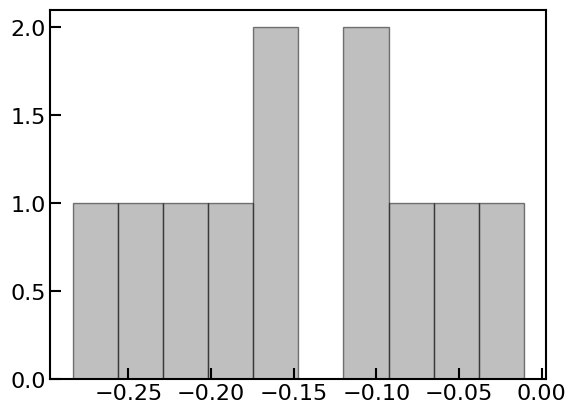

In [11]:
plt.hist(bad['Inferred B/A']-bad['ba'], bins=10, color='gray', alpha=0.5, edgecolor='black')

(array([3., 1., 4., 1., 1., 0., 0., 0., 0., 1.]),
 array([-0.24166406, -0.2187898 , -0.19591553, -0.17304127, -0.150167  ,
        -0.12729274, -0.10441848, -0.08154421, -0.05866995, -0.03579568,
        -0.01292142]),
 <BarContainer object of 10 artists>)

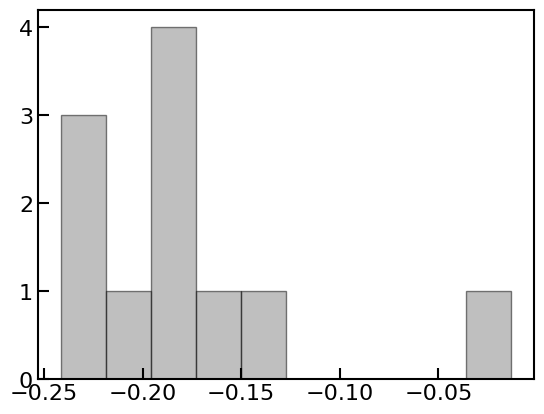

In [12]:

plt.hist(bad['Inferred C/A']-bad['ca'], bins=10, color='gray', alpha=0.5, edgecolor='black')

(array([20., 25., 24., 16.,  8.,  5.,  4.,  2.,  0.,  2.]),
 array([0.00772508, 0.04096627, 0.07420745, 0.10744863, 0.14068982,
        0.173931  , 0.20717219, 0.24041337, 0.27365456, 0.30689574,
        0.34013692]),
 <BarContainer object of 10 artists>)

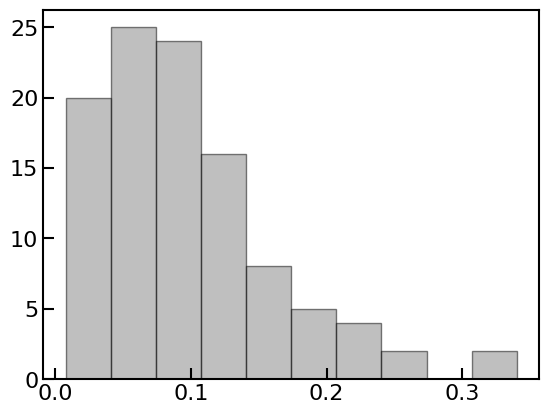

In [13]:

plt.hist(df['distance'], bins=10, color='gray', alpha=0.5, edgecolor='black')

In [14]:
print(np.mean(df['Inferred B/A']),np.mean(df['ba']))
print(np.mean(df['Inferred C/A']),np.mean(df['ca']))

0.7883951004550501 0.7977131835312187
0.39486113421503904 0.4403072841527932


0.7977131835312187 0.4403072841527932 0.1305630498365961 0.17265526252041596
0.7883951004550501 0.39486113421503904 0.15585261693448313 0.19704621063647237


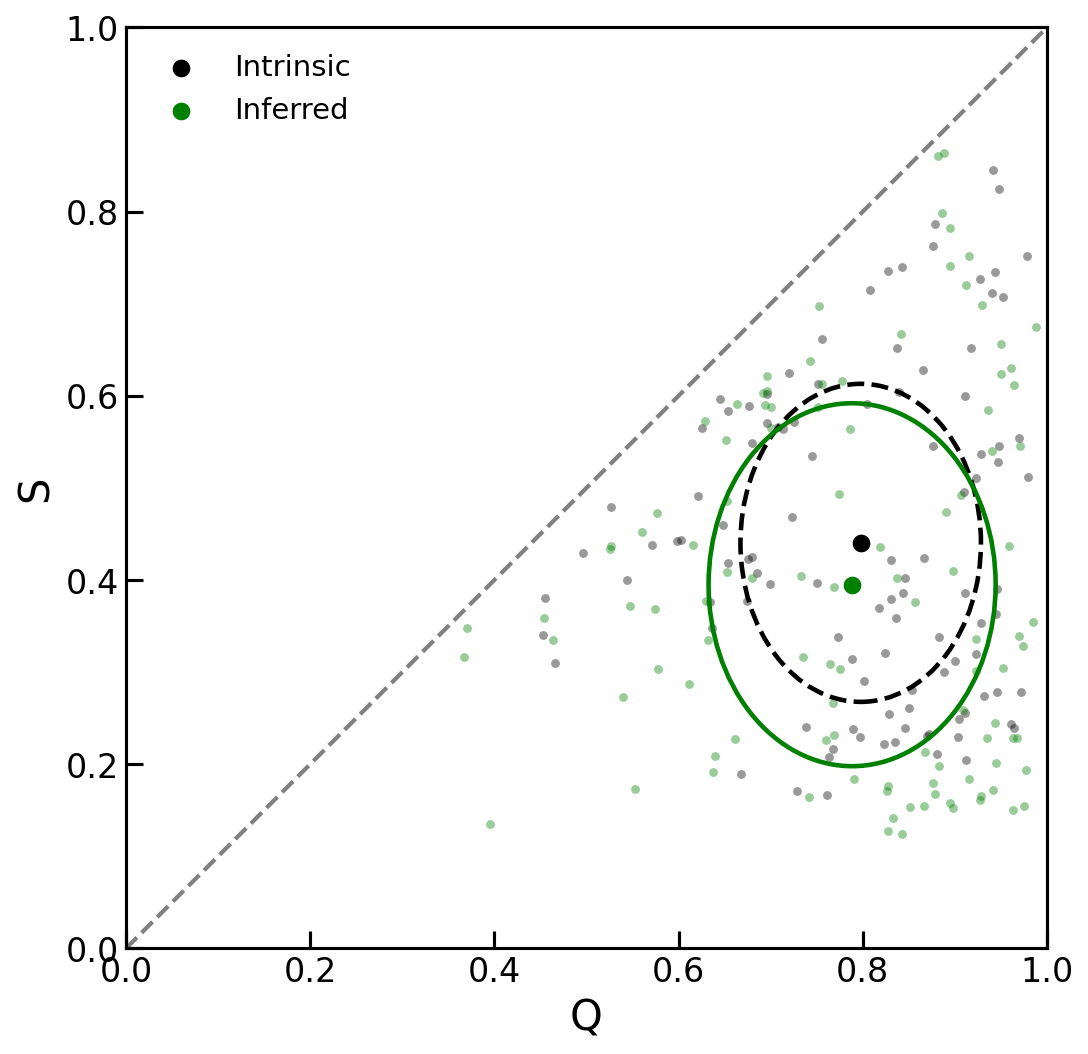

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 20,
    'axes.linewidth': 1.5,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.major.size': 8, 'ytick.major.size': 8,
    'xtick.minor.size': 4, 'ytick.minor.size': 4,
    'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
})

fig, a = plt.subplots(1, 1, figsize=(7.5, 7.5),dpi = 150)

ba_true, ca_true = df['ba'].values, df['ca'].values
ba_inf,  ca_inf  = df['Inferred B/A'].values, df['Inferred C/A'].values

# defocused individual points
pkw = dict(s=18, alpha=0.4, linewidth=0, zorder=2)
a.scatter(ba_true, ca_true, color='k',           **pkw)
a.scatter(ba_inf,  ca_inf,  color='green',    **pkw)

n_std = 1
for x, y, c, ls, lab in [(ba_true, ca_true, 'k',        '--', 'Intrinsic'),
                         (ba_inf,  ca_inf,  'green', '-',  'Inferred')]:
    mx, my = x.mean(), y.mean()
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    print(mx,my,sx,sy)
    a.add_patch(Ellipse((mx, my), width=2*n_std*sx, height=2*n_std*sy,
                        facecolor='none', edgecolor=c, ls=ls, lw=2.2, zorder=5))
    a.scatter(mx, my, s=90, color=c, edgecolor='white', linewidth=1.0,
              zorder=6, label=lab)

a.plot([0, 1], [0, 1], ls='--', c='gray', lw=2, zorder=1)
a.set(xlim=(0, 1), ylim=(0, 1), aspect='equal')
a.set_xlabel('Q')
a.set_ylabel('S')

a.legend(frameon=False, loc='upper left', fontsize=14)

fig.tight_layout()

np.float64(0.4342944819032518)

In [18]:
from shape_inference import log_likelihood
filepath = 'Marvel.DC.results/all_galaxies/all_galaxies_results.pkl'
with open(filepath, 'rb') as f:
    results = pickle.load(f)
q = results['q_obs']
params =  [0.798,0.44,0.13,0.17]
max_paramas = [0.887, 0.345, 0.086, 0.182]
ll_true, ll_inf = [],[]
for i in range(2):
    ll_true.append(log_likelihood(params,q))
    ll_inf.append(log_likelihood(max_paramas,q))

print(f'log likelhood true:     mean = {np.mean(ll_true)}, std = {np.std(ll_true)}')
print(f'log likelhood inferred: mean = {np.mean(ll_inf)}, std = {np.std(ll_inf)}')

log likelhood true:     mean = -5666.475111419073, std = 3.6104301993159424
log likelhood inferred: mean = -1296.6212754144199, std = 7.435895193425608


In [ ]:
filepath = 'Marvel.DC.results/all_galaxies_covariance/all_galaxies_results.pkl'
with open(filepath, 'rb') as f:
    results = pickle.load(f)

In [107]:
np.corrcoef(ba_true, ca_true)

array([[1.        , 0.07850444],
       [0.07850444, 1.        ]])

In [81]:

from fast_likelihood import LogLike7, attainable_fast, solve_latent_fast, get_crn, _draw,projected_semi_axes,_binned_poisson_loglike
True_params=[ 3.46614184,  0.79771318,  0.44030728,  0.76321466,  0.13056305,  0.17265526, -0.7437961]
Max_prob_params = [ 2.24320145,  0.88860608,  0.51510002,  0.80868768,  0.09951598, 0.11104923, -0.60323421]



class LogDiag(LogLike7):
    def __call__(self, theta):
        theta = np.asarray(theta, dtype=float)
        if not attainable_fast(theta):
            return -np.inf

        # --- one moment solve per call (the original did two) ---
        latent = solve_latent_fast(
            theta, get_crn(self.solve_pool, self.seed, self.dtype),)
        if latent is None:
            return -np.inf            # not attainable: this replaces the
                                      # separate attainable() pre-check

        crn = get_crn(self.n_draw_pool, self.seed, self.dtype)
        d = _draw(latent, crn)
        if d is None:
            return -np.inf
        a, b, c, keep = d
        n_good = int(keep.sum())  # inside the support
        n_bad = keep.size - n_good  # rejected
        acc = n_good / keep.size
        print(acc)

        idx = np.flatnonzero(keep)
        # if idx.size < 1000:
        #     return -np.inf
        A = a[idx]
        B = b[idx]
        C = c[idx]

        phi = crn.phi[idx]
        t = crn.theta[idx]
        alpha, beta = projected_semi_axes(phi, t, B, C)
        q = beta / alpha
        a_model = A * np.sqrt(alpha * beta)
        n_model = self._hist(q, a_model)
        total_model = n_model.sum()
        if total_model == 0:
            return -np.inf
        n_model = n_model / total_model * self.N_obs
        loglike= _binned_poisson_loglike(self.n_obs,n_model)
        print(loglike)


        #add a negative term as a penalty for losing model draws
        #loglike = loglike -(1/acc**3+1)*25

        loglike = loglike - containment_penalty(acc,hard_floor=0.5,width=0.01)
        print(loglike)
        return loglike


q = results['q_obs']
a = results['a_obs']
ll = LogDiag(q,a)




In [86]:
a = np.inf
assert a < 0

AssertionError: 

In [82]:
ll_true, ll_inf = [],[]
for i in range(1):
    ll_true.append(ll.__call__(True_params))
    ll_inf.append(ll.__call__(Max_prob_params))
print(f'log likelhood true:     mean = {np.mean(ll_true)}, std = {np.std(ll_true)}')
print(f'log likelhood inferred: mean = {np.mean(ll_inf)}, std = {np.std(ll_inf)}')

0.7750292452830189
-74296.26122087664
-74296.50876820639
0.4934783018867924
-59646.55210321244
inf
log likelhood true:     mean = -74296.50876820639, std = 0.0
log likelhood inferred: mean = inf, std = nan


In [91]:
def containment_penalty(acc, acc_min=0.8, width=0.05, hard_floor=0.50):
    """
    Smooth log-prior penalty: ~0 well above acc_min, softly negative below,
    -inf below hard_floor. Returns a value to ADD to the log-likelihood.

    Softplus form so the gradient never vanishes -- a hard cut at acc_min
    clips the posterior when the truth sits close to the boundary.
    """
    if not np.isfinite(acc) or acc < hard_floor:
        return -np.inf
    x = (acc_min - acc) / width
    return 40*float(np.logaddexp(0.0, x) ** 2)

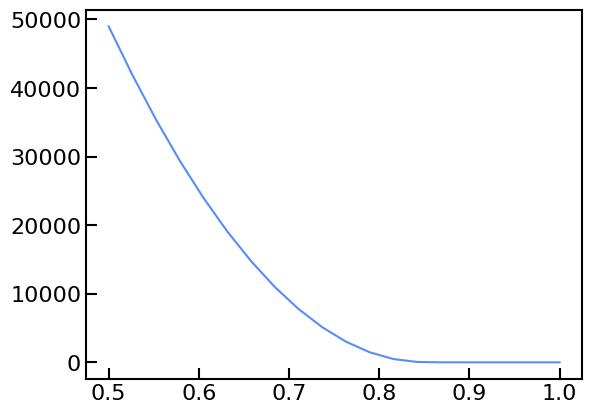

In [106]:
x=np.linspace(0.5,1,20)
y = np.zeros_like(x)
for i in range(20):
    y[i] = containment_penalty(x[i],hard_floor=0.5,acc_min=0.85,width=0.01)
plt.plot(x,y)


In [ ]:
from galaxy_ellipse_collection import cov_fit

In [ ]:
a = df['a_s']
b = df['b_s']/a
c = df['c_s']/a
cov_fit(np.log10(a),b,c)

In [ ]:
fig,ax = plt.subplots(1,3,figsize = (20,5))
ax[0].hist(a)
ax[1].hist(b)
ax[2].hist(c)